<a href="https://colab.research.google.com/github/gautham78/Smart-City-Traffic-Optimization/blob/main/Smart%20City%20Traffic%20Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import random
import pandas as pd

print("Ready: libraries OK")

green_adj_range = np.arange(-20, 41, 1)

q_len = ctrl.Antecedent(np.arange(0, 61, 1), 'queue_length')
opp_len = ctrl.Antecedent(np.arange(0, 61, 1), 'opposing_queue')
emergency = ctrl.Antecedent(np.arange(0, 2, 1), 'emergency_vehicle')
green_adj = ctrl.Consequent(green_adj_range, 'green_light_adjustment')

q_len['low'] = fuzz.trapmf(q_len.universe, [0, 0, 6, 15])
q_len['med'] = fuzz.trimf(q_len.universe, [10, 25, 40])
q_len['high'] = fuzz.trapmf(q_len.universe, [30, 45, 60, 60])

opp_len['low'] = fuzz.trapmf(opp_len.universe, [0, 0, 6, 15])
opp_len['med'] = fuzz.trimf(opp_len.universe, [10, 25, 40])
opp_len['high'] = fuzz.trapmf(opp_len.universe, [30, 45, 60, 60])

emergency['no'] = fuzz.trimf(emergency.universe, [0, 0, 0.5])
emergency['yes'] = fuzz.trimf(emergency.universe, [0.5, 1, 1])

green_adj['shrink'] = fuzz.trimf(green_adj.universe, [-20, -15, -5])
green_adj['same'] = fuzz.trimf(green_adj.universe, [-3, 0, 3])
green_adj['longer'] = fuzz.trimf(green_adj.universe, [5, 15, 25])
green_adj['force'] = fuzz.trimf(green_adj.universe, [30, 35, 40])

r1 = ctrl.Rule(q_len['high'] & opp_len['low'], green_adj['longer'])
r2 = ctrl.Rule(q_len['high'] & opp_len['med'], green_adj['longer'])
r3 = ctrl.Rule(q_len['high'] & opp_len['high'], green_adj['longer'])
r4 = ctrl.Rule(q_len['med'] & opp_len['low'], green_adj['longer'])
r5 = ctrl.Rule(q_len['med'] & opp_len['med'], green_adj['same'])
r6 = ctrl.Rule(q_len['med'] & opp_len['high'], green_adj['shrink'])
r7 = ctrl.Rule(q_len['low'] & opp_len['low'], green_adj['same'])
r8 = ctrl.Rule(q_len['low'] & opp_len['med'], green_adj['shrink'])
r9 = ctrl.Rule(q_len['low'] & opp_len['high'], green_adj['shrink'])
r10 = ctrl.Rule(emergency['yes'], green_adj['force'])

flc = ctrl.ControlSystem([r1, r2, r3, r4, r5, r6, r7, r8, r9, r10])
controller = ctrl.ControlSystemSimulation(flc)

print("Fuzzy controller ready")

Ready: libraries OK
Fuzzy controller ready


In [ ]:
NUM_JUNCTIONS = 12
SIMULATION_STEPS = 500
BASE_CYCLE_TIME = 60

class TrafficSimulation:
    def __init__(self, baseline_settings):
        self.junction_queues = {j: {'N': 0, 'S': 0, 'E': 0, 'W': 0} for j in range(NUM_JUNCTIONS)}
        self.junction_timers = {j: 0 for j in range(NUM_JUNCTIONS)}
        self.junction_phase = {j: 'N-S' for j in range(NUM_JUNCTIONS)}

        self.offsets = baseline_settings['offsets']
        self.cycle_modifiers = baseline_settings['cycle_modifiers']

        self.total_wait_time = 0
        self.total_stops = 0
        self.emergency_response_time = -1

    def run_simulation(self, use_fuzzy_logic=True):
        for step in range(SIMULATION_STEPS):
            self._add_new_arrivals()

            if step == 200:
                self.emergency_response_time = 0
                self._handle_emergency_event(junction=5, direction='N')

            self.total_wait_time += sum(sum(q.values()) for q in self.junction_queues.values())
            if self.emergency_response_time != -1:
                self.emergency_response_time += 1

            for j in range(NUM_JUNCTIONS):
                self._update_junction(j, use_fuzzy_logic)

        return self.total_wait_time, self.total_stops, self.emergency_response_time

    def _add_new_arrivals(self):
        for j in range(NUM_JUNCTIONS):
            for d in ['N', 'S', 'E', 'W']:
                new_cars = random.randint(0, 3)
                if new_cars > 0:
                    self.junction_queues[j][d] += new_cars
                    self.total_stops += new_cars

    def _handle_emergency_event(self, junction, direction):
        print(f"SIM: Emergency Vehicle approaching Junction {junction} from {direction}!")
        self.junction_phase[junction] = f"{direction}-{direction}"
        self.junction_timers[junction] = -20
        self.junction_queues[junction][direction] = 0

        if self.emergency_response_time == 0:
             self.emergency_response_time = 1

    def _update_junction(self, j, use_flc):
        self.junction_timers[j] += 1

        cycle_time = BASE_CYCLE_TIME + self.cycle_modifiers[j]

        if self.junction_timers[j] > (cycle_time / 2):
            self.junction_timers[j] = 0

            if use_flc:
                q_green, q_red = self._get_queues(j)

                clipped_q_green = max(0, min(60, q_green))
                clipped_q_red = max(0, min(60, q_red))

                controller.input['queue_length'] = clipped_q_green
                controller.input['opposing_queue'] = clipped_q_red
                controller.input['emergency_vehicle'] = (self.emergency_response_time > 0 and self.emergency_response_time < 50)

                adjustment = 0
                try:
                    controller.compute()
                    adjustment = controller.output['green_light_adjustment']
                except (ValueError, KeyError):
                    adjustment = 0

                if adjustment > 3:
                    self.junction_timers[j] = -adjustment
                else:
                    self._switch_phase(j)
            else:
                self._switch_phase(j)

        self._let_cars_pass(j)

    def _get_queues(self, j):
        if self.junction_phase[j] == 'N-S':
            q_green = max(self.junction_queues[j]['N'], self.junction_queues[j]['S'])
            q_red = max(self.junction_queues[j]['E'], self.junction_queues[j]['W'])
        else:
            q_green = max(self.junction_queues[j]['E'], self.junction_queues[j]['W'])
            q_red = max(self.junction_queues[j]['N'], self.junction_queues[j]['S'])
        return q_green, q_red

    def _switch_phase(self, j):
        self.junction_phase[j] = 'E-W' if self.junction_phase[j] == 'N-S' else 'N-S'

    def _let_cars_pass(self, j):
        if self.junction_phase[j] == 'N-S':
            self.junction_queues[j]['N'] = max(0, self.junction_queues[j]['N'] - 1)
            self.junction_queues[j]['S'] = max(0, self.junction_queues[j]['S'] - 1)
        elif self.junction_phase[j] == 'E-W':
            self.junction_queues[j]['E'] = max(0, self.junction_queues[j]['E'] - 1)
            self.junction_queues[j]['W'] = max(0, self.junction_queues[j]['W'] - 1)
        elif self.junction_phase[j].count('-') == 1:
            d = self.junction_phase[j].split('-')[0]
            self.junction_queues[j][d] = 0

POPULATION_SIZE = 40
NUM_GENERATIONS = 60
MUTATION_RATE = 0.1

def calculate_fitness(chromosome):
    offsets = chromosome[:NUM_JUNCTIONS]
    cycle_mods = chromosome[NUM_JUNCTIONS:]
    settings = {'offsets': offsets, 'cycle_modifiers': cycle_mods}

    sim = TrafficSimulation(settings)
    wait, stops, _ = sim.run_simulation(use_fuzzy_logic=False)

    offset_penalty = sum(abs(offsets[i] - offsets[i-1]) for i in range(1, NUM_JUNCTIONS)) * 5

    total_score = wait + stops + offset_penalty
    return 1000000.0 / total_score

def create_individual():
    chromosome = []
    for _ in range(NUM_JUNCTIONS):
        chromosome.append(random.randint(0, 60))
    for _ in range(NUM_JUNCTIONS):
        chromosome.append(random.randint(-10, 20))
    return chromosome

def crossover(parent1, parent2):
    point = len(parent1) // 2
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def mutate(individual):
    for i in range(len(individual)):
        if random.random() < MUTATION_RATE:
            change = random.randint(-5, 5)
            if i < NUM_JUNCTIONS:
                individual[i] = max(0, min(60, individual[i] + change))
            else:
                individual[i] = max(-10, min(20, individual[i] + change))
    return individual

print("Starting Genetic Algorithm to optimize baseline timings...")
population = [create_individual() for _ in range(POPULATION_SIZE)]
best_fitness_over_time = []

for gen in range(NUM_GENERATIONS):
    fitness_scores = [calculate_fitness(ind) for ind in population]
    best_fitness_over_time.append(max(fitness_scores))

    sorted_pop = [x for _, x in sorted(zip(fitness_scores, population), reverse=True)]

    next_generation = sorted_pop[:POPULATION_SIZE // 2]

    while len(next_generation) < POPULATION_SIZE:
        parent1, parent2 = random.sample(sorted_pop[:POPULATION_SIZE // 2], 2)
        child1, child2 = crossover(parent1, parent2)
        next_generation.append(mutate(child1))
        if len(next_generation) < POPULATION_SIZE:
            next_generation.append(mutate(child2))

    population = next_generation

    if (gen + 1) % 10 == 0:
        print(f"Gen {gen+1}/{NUM_GENERATIONS}, Best Fitness: {max(fitness_scores):.2f}")

final_fitness_scores = [calculate_fitness(ind) for ind in population]
best_index = final_fitness_scores.index(max(final_fitness_scores))
best_chromosome = population[best_index]
best_settings = {
    'offsets': best_chromosome[:NUM_JUNCTIONS],
    'cycle_modifiers': best_chromosome[NUM_JUNCTIONS:]
}

print("Genetic Algorithm finished.")
print("Best offsets:", best_settings['offsets'])
print("Cycle mods:", best_settings['cycle_modifiers'])

Starting Genetic Algorithm to optimize baseline timings...
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle 

In [ ]:
print("Running simulations to compare 'Before' and 'After'...")

before_settings = {'offsets': [0] * NUM_JUNCTIONS, 'cycle_modifiers': [0] * NUM_JUNCTIONS}
sim_before = TrafficSimulation(before_settings)
wait_before, stops_before, emergency_before = sim_before.run_simulation(use_fuzzy_logic=False)

sim_after = TrafficSimulation(best_settings)
wait_after, stops_after, emergency_after = sim_after.run_simulation(use_fuzzy_logic=True)

print("Simulations complete.")

Running simulations to compare 'Before' and 'After'...
SIM: Emergency Vehicle approaching Junction 5 from N!
SIM: Emergency Vehicle approaching Junction 5 from N!
Simulations complete.



RESULTS
Offsets: [60, 60, 49, 16, 32, 60, 9, 0, 52, 37, 18, 36]
Cycle adjustments: [7, 15, 19, -3, 7, -6, 19, 1, 12, 6, 20, 10]

--- Simulation Results ---
Metric                   | Before (Baseline)  | After (GA + FLC)   | Improvement (%)
-----------------------------------------------------------------------------------
Total Wait Time (s)      |          5,967,679 |          5,942,704 |             0.4%
Total Stops              |             35,861 |             35,840 |             0.1%
Emergency Response Time (s)|                301 |                301 |             N/A


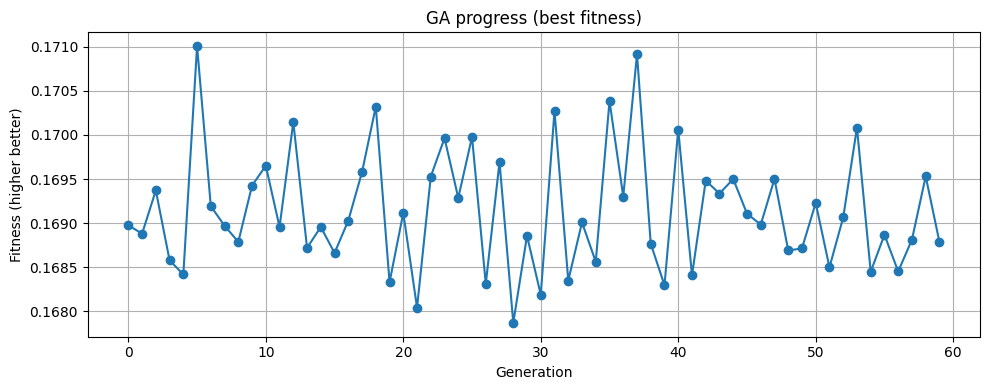

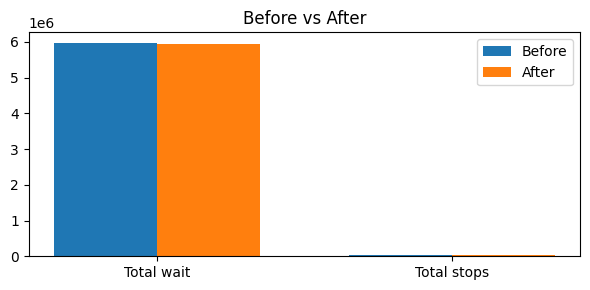


Sample FLC outputs:
gQ=5, rQ=2, em=0 -> adjust -0.0s
gQ=35, rQ=5, em=0 -> adjust 15.0s
gQ=40, rQ=10, em=1 -> adjust 22.7s
Done.


In [ ]:
print("\nRESULTS")
print("Offsets:", best_settings['offsets'])
print("Cycle adjustments:", best_settings['cycle_modifiers'])

print("\n--- Simulation Results ---")
print(f"Metric                   | Before (Baseline)  | After (GA + FLC)   | Improvement (%)")
print(f"-----------------------------------------------------------------------------------")

wait_diff = wait_before - wait_after
wait_percent_improvement = (wait_diff / wait_before * 100) if wait_before > 0 else 0
print(f"Total Wait Time (s)      | {wait_before:>18,} | {wait_after:>18,} | {wait_percent_improvement:>15.1f}%")

stops_diff = stops_before - stops_after
stops_percent_improvement = (stops_diff / stops_before * 100) if stops_before > 0 else 0
print(f"Total Stops              | {stops_before:>18,} | {stops_after:>18,} | {stops_percent_improvement:>15.1f}%")

print(f"Emergency Response Time (s)| {emergency_before:>18,} | {emergency_after:>18,} | {'N/A':>15}")

plt.figure(figsize=(10,4))
plt.plot(best_fitness_over_time, '-o')
plt.title("GA progress (best fitness)")
plt.xlabel("Generation")
plt.ylabel("Fitness (higher better)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,3))
labels = ['Total wait', 'Total stops']
before_vals = [wait_before, stops_before]
after_vals = [wait_after, stops_after]
x = np.arange(len(labels))
w = 0.35
plt.bar(x - w/2, before_vals, width=w, label='Before')
plt.bar(x + w/2, after_vals, width=w, label='After')
plt.xticks(x, labels)
plt.legend()
plt.title("Before vs After")
plt.tight_layout()
plt.show()

print("\nSample FLC outputs:")
for qg, qr, em in [(5,2,0), (35,5,0), (40,10,1)]:
    controller.input['queue_length'] = qg
    controller.input['opposing_queue'] = qr
    controller.input['emergency_vehicle'] = em

    adjustment = 0
    try:
        controller.compute()
        adjustment = controller.output['green_light_adjustment']
    except (ValueError, KeyError):
        adjustment = 0

    print(f"gQ={qg}, rQ={qr}, em={em} -> adjust {adjustment:.1f}s")

print("Done.")